In [1]:
import numpy as np
import pandas as pd

import risk_kit as rk
%load_ext autoreload
%autoreload 2

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:67: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if filetype is "returns":
C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:70: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif filetype is "nfirms":
C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:73: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif filetype is "size":


In [2]:
ind49_rets = rk.get_ind_returns(weighting="vw", n_inds=49)["1974":]
ind49_mcap = rk.get_ind_market_caps(49, weights=True)["1974":]

In this section we'll develop a basic infrastructure to backtest various portfolio construction techniques and compare them. Here we'll start with something quite simple and straightforward - we'll write trivially simple weight-optimizers for Equally Weighted and Cap Weighted portfolios and compare them. Obviously, there are no Covariance estimates required for either one of these weighting schemes. In following sessions we'll enhance these optimizers to use more complex weighting schemes that will rely on covariance estimates.

In [3]:
def weight_ew(r):
    """
    Returns the weights of the EW portfolio based on the asset returns "r" as a DataFrame
    """
    n = len(r.columns)
    return pd.Series(1/n, index=r.columns)

def backtest_ws(r, estimation_window=60, weighting=weight_ew):
    """
    Backtests a given weighting scheme, given some parameters:
    r : asset returns to use to build the portfolio
    estimation_window: the window to use to estimate parameters
    weighting: the weighting scheme to use, must be a function that takes "r", and a variable number of keyword-value arguments
    """
    n_periods = r.shape[0]

    windows = [(start, start+estimation_window) for start in range(n_periods-estimation_window+1)]
    # windows is a list of tuples which gives us the (integer) location of the start and stop (non inclusive)
    # for each estimation window
    weights = [weighting(r.iloc[win[0]:win[1]]) for win in windows]
    # List -> DataFrame
    weights = pd.DataFrame(weights, index=r.iloc[estimation_window-1:].index, columns=r.columns)
    # return weights
    returns = (weights * r).sum(axis="columns",  min_count=1) #mincount is to generate NAs if all inputs are NAs
    return returns

In [4]:
ewr = backtest_ws(ind49_rets, weighting=weight_ew)

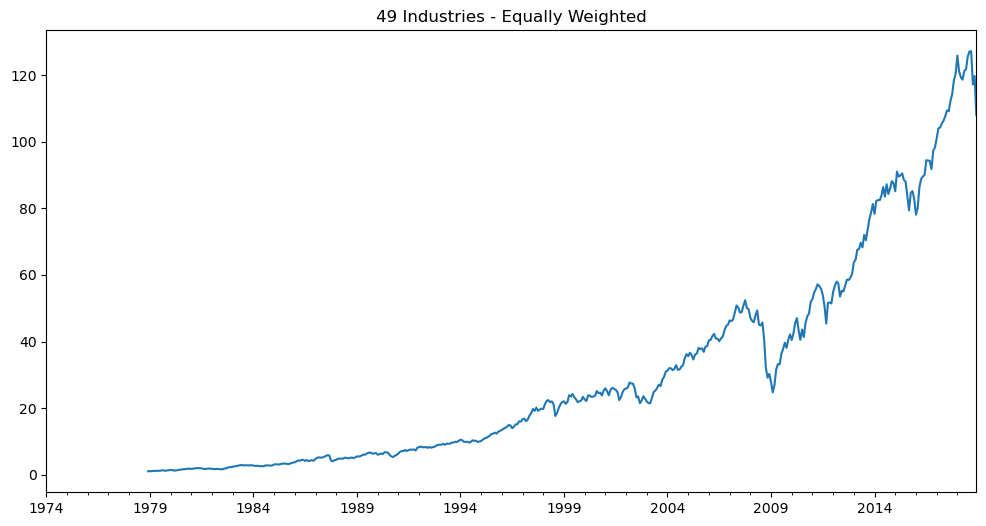

In [5]:
ewi = (1+ewr).cumprod()
ewi.plot(figsize=(12,6), title="49 Industries - Equally Weighted");

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.123629,0.160821,-0.757144,6.645047,0.071496,0.103955,0.566462,-0.528292
CW,0.117303,0.151183,-0.743452,5.346694,0.068156,0.097848,0.561875,-0.501246


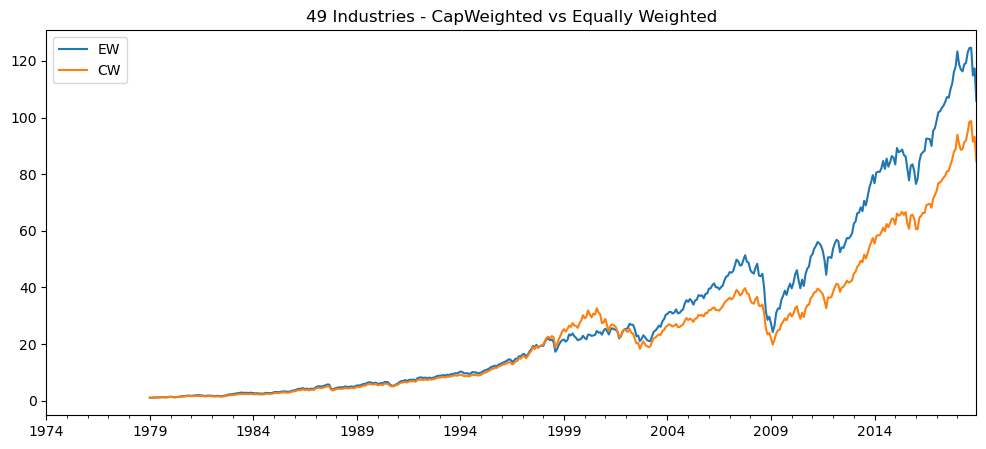

In [6]:
ewr = rk.backtest_ws(ind49_rets)
cwr = rk.backtest_ws(ind49_rets, weighting=rk.weight_cw, cap_weights=ind49_mcap)
btr = pd.DataFrame({"EW": ewr, "CW": cwr})
(1+btr).cumprod().plot(figsize=(12,5), title="49 Industries - CapWeighted vs Equally Weighted")
rk.summary_stats(btr.dropna())

# Improving EW with CapWeight Tethering

Often in practice, we'll want to implement some sort of a modification of a pure strategy. For instance, although Equal Weight portfolios are popular, they'll be constrained in some way - for instance to match the sector weights of the cap-weighted benchmark or to make sure that microcap stocks are not overweighted. The motivation for doing so could be to make a portfolio more tradeable (e.g. some microcaps may not have the liquidity) or to improve the tracking error to the Cap-Weighted index.

As an illustration of how that can be achieved, we enhance our simple `weight_ew` allocator to (i) drop microcap stocks beyond a particular threshold, and (ii) impose a constraint that ensures that the maximum weight assigned to any stock is no more than some multiple of the weight it would be in a cap-weighted portfolio.

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.123629,0.160821,-0.757144,6.645047,0.071496,0.103955,0.566462,-0.528292
EW-Tethered,0.122366,0.155859,-0.808126,6.256922,0.070052,0.100122,0.576626,-0.527229
CW,0.117303,0.151183,-0.743452,5.346694,0.068156,0.097848,0.561875,-0.501246


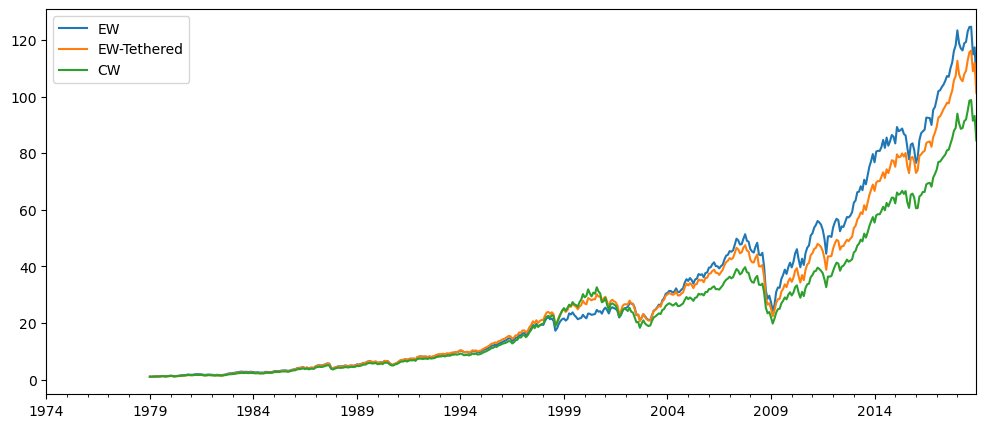

In [7]:
ewr = rk.backtest_ws(ind49_rets)
ewtr = rk.backtest_ws(ind49_rets, cap_weights=ind49_mcap, max_cw_mult=5, microcap_threshold=.005)
cwr = rk.backtest_ws(ind49_rets, weighting=rk.weight_cw, cap_weights=ind49_mcap)
btr = pd.DataFrame({"EW": ewr, "EW-Tethered": ewtr, "CW": cwr})
(1+btr).cumprod().plot(figsize=(12,5))
rk.summary_stats(btr.dropna())

In [8]:
estimation_window=60

n_periods = ind49_mcap.shape[0]
# return windows
windows = [(start, start+estimation_window) 
               for start in range(n_periods-estimation_window)]
weights = [rk.weight_ew(ind49_mcap.iloc[win[0]:win[1]], cap_weights=ind49_mcap, max_cw_mult=5, microcap_threshold=.005) for win in windows]
# convert List of weights to DataFrame
weights = pd.DataFrame(weights, index=ind49_mcap.iloc[estimation_window:].index, 
                       columns=ind49_mcap.columns)
print(weights.head())

         Agric      Food      Soda  Beer     Smoke  Toys       Fun     Books  \
1979-01    0.0  0.029602  0.029602   0.0  0.029602   0.0  0.026881  0.029602   
1979-02    0.0  0.029583  0.029583   0.0  0.029583   0.0  0.027522  0.029583   
1979-03    0.0  0.029537  0.029537   0.0  0.029537   0.0  0.027606  0.029537   
1979-04    0.0  0.029557  0.029557   0.0  0.029557   0.0  0.026810  0.029557   
1979-05    0.0  0.029534  0.029534   0.0  0.029534   0.0  0.026936  0.029534   

            Hshld     Clths  ...     Boxes     Trans     Whlsl     Rtail  \
1979-01  0.029602  0.026065  ...  0.029602  0.029602  0.029602  0.029602   
1979-02  0.029583  0.025822  ...  0.029583  0.029583  0.029583  0.029583   
1979-03  0.029537  0.027215  ...  0.029537  0.029537  0.029537  0.029537   
1979-04  0.029557  0.027375  ...  0.029557  0.029557  0.029557  0.029557   
1979-05  0.029534  0.027969  ...  0.029534  0.029534  0.029534  0.029534   

            Meals     Banks     Insur  RlEst       Fin     Oth

In [9]:
w_sum = weights.sum(axis=1)
w_sum

1979-01    1.0
1979-02    1.0
1979-03    1.0
1979-04    1.0
1979-05    1.0
          ... 
2018-08    1.0
2018-09    1.0
2018-10    1.0
2018-11    1.0
2018-12    1.0
Freq: M, Length: 480, dtype: float64

#### One of the motivations of adding the tethering constraint is to improve tracking error to the cap-weighted portfolio. Let's see if we did manage to achieve that:

In [10]:
rk.tracking_error(ewr, cwr),rk.tracking_error(ewtr, cwr)

(np.float64(0.28559589992488), np.float64(0.19290989465760422))